# Atmospheric Basic State Changes at 850 hPa (P1 vs P2)

This notebook generates a publication-quality 2 × 3 global map figure showing differences in the atmospheric basic state between **P1 (1981–2006)** and **P2 (2007–2025)**:
- **Top row:** Air temperature ($T$, shaded) overlaid with horizontal wind vectors ($u, v$) at 850 hPa ($\sigma = 0.83$).
- **Bottom row:** Specific humidity ($q$, shaded) at 850 hPa ($\sigma = 0.83$).

### Dataset & Methodology
- **Input NetCDF:** `/Users/rizzie/LinearBaroclinicModel/make_basic_state/output/basic_state_ncep_r2_era5sst_djf_all_periods.nc`
- **Atmospheric basic state:** NCEP/DOE Reanalysis 2 (DJF climatologies)
- **Vertical level:** Selected terrain-following sigma level $\sigma = 0.82977$ (level index 4), corresponding to $\sim$841 hPa assuming nominal surface pressure of 1013.25 hPa (or $\sim$830 hPa at 1000 hPa), which is the closest available sigma level to 850 hPa.
- **Climatological Periods:**
  - P1: 1981–2006 (period index 1)
  - P2: 2007–2025 (period index 2)
- **Units:** Temperature in °C, specific humidity in $\mathrm{g\ kg^{-1}}$, horizontal wind in $\mathrm{m\ s^{-1}}$.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.util as cutil
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Matplotlib font and aesthetic configuration matching publication reference
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Helvetica Neue', 'Arial', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['font.size'] = 11

In [2]:
# 1. Load dataset and inspect structure
nc_path = '/Users/rizzie/LinearBaroclinicModel/make_basic_state/output/basic_state_ncep_r2_era5sst_djf_all_periods.nc'
ds = xr.open_dataset(nc_path)

print("=== DATASET STRUCTURE ===")
print("Dimensions:", dict(ds.dims))
print("Coordinates:", list(ds.coords.keys()))
print("Variables:", list(ds.data_vars.keys()))
print("\nClimatological Periods in dataset:")
for i, name in enumerate(ds.period_name.values):
    p_str = name.decode() if isinstance(name, bytes) else str(name)
    print(f"  Index {i}: {p_str} ({ds.period_start_year.values[i]}–{ds.period_end_year.values[i]})")

=== DATASET STRUCTURE ===
Dimensions: {'period': 3, 'sigma': 20, 'lat': 32, 'lon': 64}
Coordinates: ['period', 'period_name', 'sigma', 'lat', 'lon']
Variables: ['period_start_year', 'period_end_year', 'u', 'v', 't', 'q', 'p', 'sst']

Climatological Periods in dataset:
  Index 0: 1981-2025 (1981–2025)
  Index 1: 1981-2006 (1981–2006)
  Index 2: 2007-2025 (2007–2025)


In [3]:
# 2. Vertical level selection and metadata verification
# Identify sigma level closest to 850 hPa assuming nominal Ps ~ 1000-1013.25 hPa
target_p = 850.0  # hPa
nominal_ps = 1013.25  # hPa
target_sigma = target_p / nominal_ps
closest_idx = int(np.argmin(np.abs(ds.sigma.values - target_sigma)))
sig_val = float(ds.sigma.values[closest_idx])

print(f"Target pressure: {target_p} hPa")
print(f"Selected sigma level: index {closest_idx} (sigma = {sig_val:.5f}, ~{sig_val * nominal_ps:.1f} hPa at Ps=1013.25 hPa)")

# Period indices: P1 (1981-2006) = 1, P2 (2007-2025) = 2
idx_p1 = 1
idx_p2 = 2

# 3. Extract variables and apply unit conversions
# Air temperature: K -> °C
t_p1 = (ds['t'].isel(period=idx_p1, sigma=closest_idx) - 273.15).values
t_p2 = (ds['t'].isel(period=idx_p2, sigma=closest_idx) - 273.15).values
t_diff = t_p2 - t_p1

# Specific humidity: kg kg-1 -> g kg-1
q_p1 = (ds['q'].isel(period=idx_p1, sigma=closest_idx) * 1000.0).values
q_p2 = (ds['q'].isel(period=idx_p2, sigma=closest_idx) * 1000.0).values
q_diff = q_p2 - q_p1

# Horizontal wind components: m s-1
u_p1 = ds['u'].isel(period=idx_p1, sigma=closest_idx).values
u_p2 = ds['u'].isel(period=idx_p2, sigma=closest_idx).values
u_diff = u_p2 - u_p1

v_p1 = ds['v'].isel(period=idx_p1, sigma=closest_idx).values
v_p2 = ds['v'].isel(period=idx_p2, sigma=closest_idx).values
v_diff = v_p2 - v_p1

lons = ds.lon.values
lats = ds.lat.values

# 4. Print robustness verification checks
print("\n=== ROBUSTNESS VERIFICATION ===")
print(f"Selected variables and units:")
print(f"  - Air Temperature (t): converted from K to °C")
print(f"  - Specific Humidity (q): converted from kg kg-1 to g kg-1")
print(f"  - Zonal Wind (u): m s-1")
print(f"  - Meridional Wind (v): m s-1")
print(f"Vertical level: sigma = {sig_val:.5f} (index {closest_idx})")
print(f"Periods: P1 = {ds.period_name.values[idx_p1].decode()} (idx {idx_p1}), P2 = {ds.period_name.values[idx_p2].decode()} (idx {idx_p2})")
print(f"\nMin/Max values after conversion:")
print(f"  T_P1   : min = {t_p1.min():.2f} °C, max = {t_p1.max():.2f} °C")
print(f"  T_P2   : min = {t_p2.min():.2f} °C, max = {t_p2.max():.2f} °C")
print(f"  T_diff : min = {t_diff.min():.2f} °C, max = {t_diff.max():.2f} °C")
print(f"  q_P1   : min = {q_p1.min():.2f} g kg-1, max = {q_p1.max():.2f} g kg-1")
print(f"  q_P2   : min = {q_p2.min():.2f} g kg-1, max = {q_p2.max():.2f} g kg-1")
print(f"  q_diff : min = {q_diff.min():.2f} g kg-1, max = {q_diff.max():.2f} g kg-1")
print(f"  u_P1   : min = {u_p1.min():.2f} m s-1, max = {u_p1.max():.2f} m s-1")
print(f"  u_P2   : min = {u_p2.min():.2f} m s-1, max = {u_p2.max():.2f} m s-1")
print(f"  u_diff : min = {u_diff.min():.2f} m s-1, max = {u_diff.max():.2f} m s-1")
print(f"  v_P1   : min = {v_p1.min():.2f} m s-1, max = {v_p1.max():.2f} m s-1")
print(f"  v_P2   : min = {v_p2.min():.2f} m s-1, max = {v_p2.max():.2f} m s-1")
print(f"  v_diff : min = {v_diff.min():.2f} m s-1, max = {v_diff.max():.2f} m s-1")

Target pressure: 850.0 hPa
Selected sigma level: index 4 (sigma = 0.82977, ~840.8 hPa at Ps=1013.25 hPa)

=== ROBUSTNESS VERIFICATION ===
Selected variables and units:
  - Air Temperature (t): converted from K to °C
  - Specific Humidity (q): converted from kg kg-1 to g kg-1
  - Zonal Wind (u): m s-1
  - Meridional Wind (v): m s-1
Vertical level: sigma = 0.82977 (index 4)
Periods: P1 = 1981-2006 (idx 1), P2 = 2007-2025 (idx 2)

Min/Max values after conversion:
  T_P1   : min = -36.97 °C, max = 20.67 °C
  T_P2   : min = -35.36 °C, max = 21.10 °C
  T_diff : min = -0.79 °C, max = 3.20 °C
  q_P1   : min = 0.17 g kg-1, max = 11.74 g kg-1
  q_P2   : min = 0.18 g kg-1, max = 12.32 g kg-1
  q_diff : min = -0.83 g kg-1, max = 1.40 g kg-1
  u_P1   : min = -11.31 m s-1, max = 16.12 m s-1
  u_P2   : min = -11.32 m s-1, max = 16.54 m s-1
  u_diff : min = -2.79 m s-1, max = 4.98 m s-1
  v_P1   : min = -6.89 m s-1, max = 6.49 m s-1
  v_P2   : min = -6.61 m s-1, max = 7.31 m s-1
  v_diff : min = -2.25

Saved publication figures:
  - basic_state_T_q_wind_850hPa_P1_P2.png
  - basic_state_T_q_wind_850hPa_P1_P2.pdf


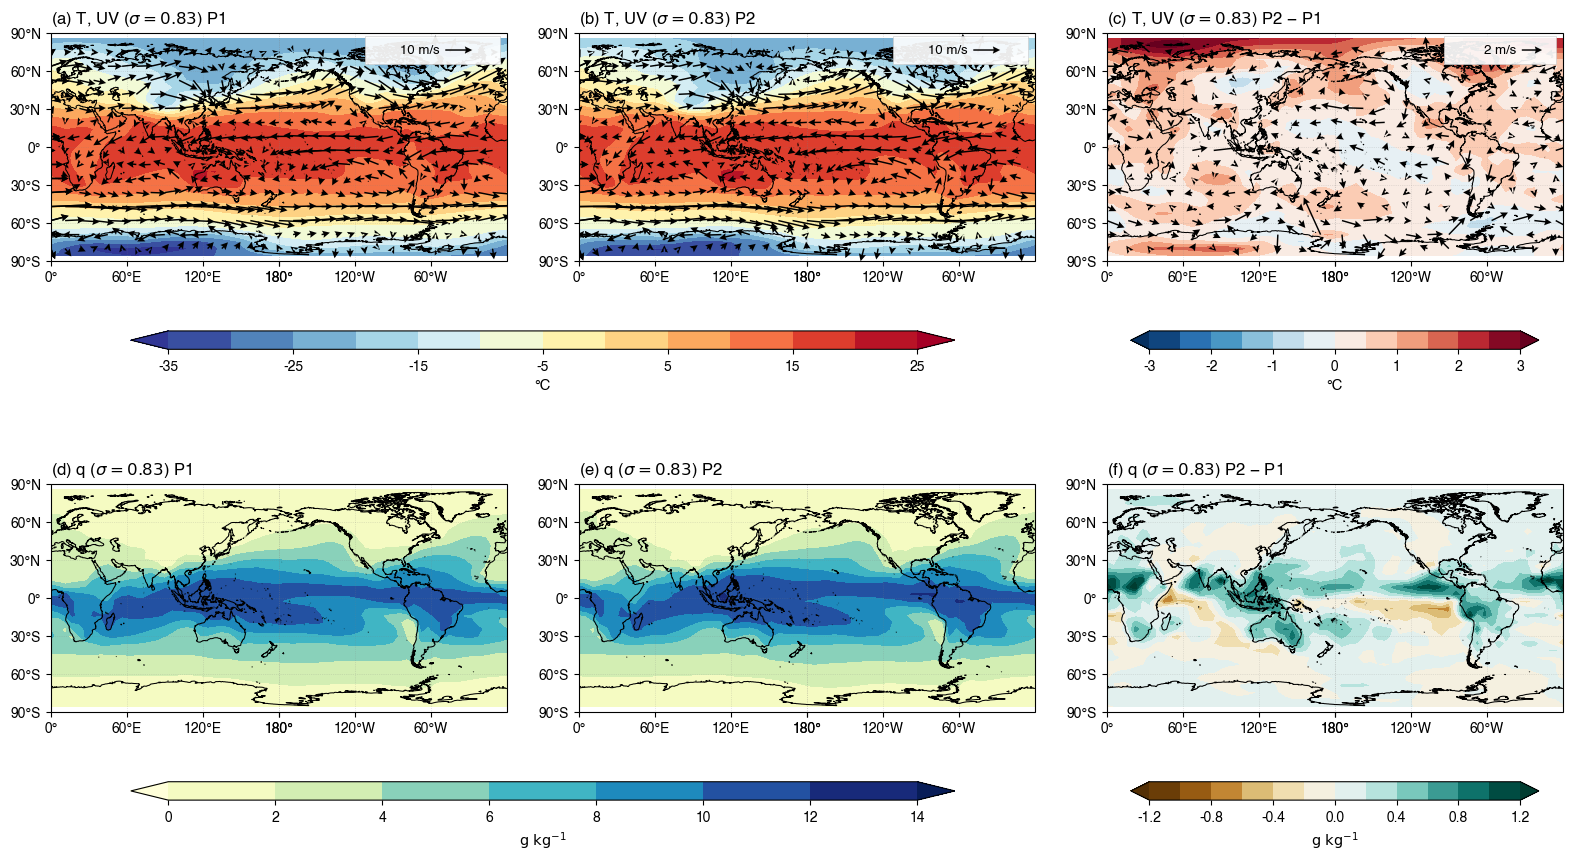

In [4]:
# 5. Add cyclic point to prevent seam at 0°/360° longitude
c_t_p1, c_lon = cutil.add_cyclic_point(t_p1, coord=lons)
c_t_p2, _ = cutil.add_cyclic_point(t_p2, coord=lons)
c_t_diff, _ = cutil.add_cyclic_point(t_diff, coord=lons)

c_q_p1, _ = cutil.add_cyclic_point(q_p1, coord=lons)
c_q_p2, _ = cutil.add_cyclic_point(q_p2, coord=lons)
c_q_diff, _ = cutil.add_cyclic_point(q_diff, coord=lons)

c_u_p1, _ = cutil.add_cyclic_point(u_p1, coord=lons)
c_v_p1, _ = cutil.add_cyclic_point(v_p1, coord=lons)

c_u_p2, _ = cutil.add_cyclic_point(u_p2, coord=lons)
c_v_p2, _ = cutil.add_cyclic_point(v_p2, coord=lons)

c_u_diff, _ = cutil.add_cyclic_point(u_diff, coord=lons)
c_v_diff, _ = cutil.add_cyclic_point(v_diff, coord=lons)

# Subsampling grid for quiver vectors
lon_2d, lat_2d = np.meshgrid(c_lon, lats)

# Quiver styling matching Fig5 (minshaft=0, fixed head geometry, clean in-panel key box)
arrow_width = 0.0032
head_scale = 0.0020 / arrow_width

# Vector strides: exclude polar edge rows (lat index 0 and -1 at ±85.8°) to avoid border crowding
# For climatological winds (a, b): stride 2 in lat, 2 in lon (495 vectors)
# For difference winds (c): reduced density by ~33% (stride 2 in lat, 3 in lon, 330 vectors) for clearer circulation
stride_ab = (slice(1, -1, 2), slice(None, None, 2))
stride_c  = (slice(1, -1, 2), slice(None, None, 3))

# 6. Set up 2 × 3 publication-quality figure
fig = plt.figure(figsize=(16, 9.2))

proj = ccrs.PlateCarree(central_longitude=180)
lon_formatter = LongitudeFormatter(cardinal_labels={'east': 'E', 'west': 'W'})
lat_formatter = LatitudeFormatter(cardinal_labels={'north': 'N', 'south': 'S'})

def style_subplot(ax, title):
    ax.coastlines(resolution='50m', color='black', linewidth=0.75, zorder=3)
    ax.gridlines(xlocs=np.arange(-180, 181, 60), ylocs=np.arange(-90, 91, 30),
                 crs=ccrs.PlateCarree(), draw_labels=False, linewidth=0.5,
                 color='gray', alpha=0.35, linestyle=':')
    ax.set_xticks(np.arange(-180, 181, 60), crs=ccrs.PlateCarree())
    ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
    ax.xaxis.set_major_formatter(lon_formatter)
    ax.yaxis.set_major_formatter(lat_formatter)
    ax.tick_params(labelsize=10, direction='out')
    ax.set_title(title, fontsize=12, pad=7, loc='left', fontname='Helvetica', fontweight='normal')

# Geometric layout parameters for subplots and colorbars
map_w = 0.285
map_h = 0.310
gap_x = 0.045
left_margin = 0.050
col_lefts = [left_margin + i * (map_w + gap_x) for i in range(3)]
row_tops = [0.93, 0.44]
row_bottoms = [row_tops[r] - map_h for r in range(2)]
cbar_h = 0.020
cbar_pad = 0.065

# Contour levels and colormaps
# Air temperature (a, b): -35 to 25 °C, step 5 °C
levels_t = np.arange(-35, 26, 5)
norm_t = mcolors.Normalize(vmin=-35, vmax=25)
cmap_t = plt.cm.RdYlBu_r

# Air temperature difference (c): revised to ±3.0 °C, step 0.5 °C
levels_t_diff = np.arange(-3.0, 3.01, 0.5)
norm_t_diff = mcolors.Normalize(vmin=-3.0, vmax=3.0)
cmap_t_diff = plt.cm.RdBu_r

# Specific humidity (d, e): 0 to 14 g kg-1, step 2 g kg-1
levels_q = np.arange(0, 14.1, 2)
norm_q = mcolors.Normalize(vmin=0, vmax=14)
cmap_q = plt.cm.YlGnBu

# Specific humidity difference (f): revised to ±1.2 g kg-1, step 0.2 g kg-1 (captures 99.8% of global grid)
levels_q_diff = np.arange(-1.2, 1.21, 0.2)
norm_q_diff = mcolors.Normalize(vmin=-1.2, vmax=1.2)
cmap_q_diff = plt.cm.BrBG

# --- TOP ROW: Air Temperature & Wind Vectors ---
# (a) P1
ax_a = fig.add_axes([col_lefts[0], row_bottoms[0], map_w, map_h], projection=proj)
im_a = ax_a.contourf(c_lon, lats, c_t_p1, levels=levels_t, cmap=cmap_t, norm=norm_t,
                     transform=ccrs.PlateCarree(), extend='both')
q_a = ax_a.quiver(lon_2d[stride_ab], lat_2d[stride_ab],
                  c_u_p1[stride_ab], c_v_p1[stride_ab],
                  transform=ccrs.PlateCarree(), color='black', scale=170,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

# In-panel white reference key box matching Fig5
key_box_a = mpatches.Rectangle((0.69, 0.865), 0.295, 0.12, transform=ax_a.transAxes,
                               facecolor='white', edgecolor='#cccccc', linewidth=0.5, alpha=0.92, zorder=5)
ax_a.add_patch(key_box_a)
qk_a = ax_a.quiverkey(q_a, X=0.865, Y=0.925, U=10.0, label='10 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 9.5}, labelsep=0.06)
qk_a.set_zorder(6)
qk_a.text.set_zorder(7)
style_subplot(ax_a, r"(a) T, UV ($\sigma = 0.83$) P1")

# (b) P2
ax_b = fig.add_axes([col_lefts[1], row_bottoms[0], map_w, map_h], projection=proj)
im_b = ax_b.contourf(c_lon, lats, c_t_p2, levels=levels_t, cmap=cmap_t, norm=norm_t,
                     transform=ccrs.PlateCarree(), extend='both')
q_b = ax_b.quiver(lon_2d[stride_ab], lat_2d[stride_ab],
                  c_u_p2[stride_ab], c_v_p2[stride_ab],
                  transform=ccrs.PlateCarree(), color='black', scale=170,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

key_box_b = mpatches.Rectangle((0.69, 0.865), 0.295, 0.12, transform=ax_b.transAxes,
                               facecolor='white', edgecolor='#cccccc', linewidth=0.5, alpha=0.92, zorder=5)
ax_b.add_patch(key_box_b)
qk_b = ax_b.quiverkey(q_b, X=0.865, Y=0.925, U=10.0, label='10 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 9.5}, labelsep=0.06)
qk_b.set_zorder(6)
qk_b.text.set_zorder(7)
style_subplot(ax_b, r"(b) T, UV ($\sigma = 0.83$) P2")

# (c) P2 - P1
ax_c = fig.add_axes([col_lefts[2], row_bottoms[0], map_w, map_h], projection=proj)
im_c = ax_c.contourf(c_lon, lats, c_t_diff, levels=levels_t_diff, cmap=cmap_t_diff, norm=norm_t_diff,
                     transform=ccrs.PlateCarree(), extend='both')
q_c = ax_c.quiver(lon_2d[stride_c], lat_2d[stride_c],
                  c_u_diff[stride_c], c_v_diff[stride_c],
                  transform=ccrs.PlateCarree(), color='black', scale=45,
                  width=arrow_width,
                  headwidth=8 * head_scale, headlength=8 * head_scale, headaxislength=7 * head_scale,
                  minshaft=0, minlength=0, zorder=4)

key_box_c = mpatches.Rectangle((0.74, 0.865), 0.245, 0.12, transform=ax_c.transAxes,
                               facecolor='white', edgecolor='#cccccc', linewidth=0.5, alpha=0.92, zorder=5)
ax_c.add_patch(key_box_c)
qk_c = ax_c.quiverkey(q_c, X=0.91, Y=0.925, U=2.0, label='2 m/s',
                      labelpos='W', coordinates='axes',
                      fontproperties={'family': 'Helvetica', 'size': 9.5}, labelsep=0.06)
qk_c.set_zorder(6)
qk_c.text.set_zorder(7)
style_subplot(ax_c, r"(c) T, UV ($\sigma = 0.83$) P2 − P1")

# Colorbars for Top Row
# Shared colorbar for (a, b)
cbar_ab_left = col_lefts[0] + 0.05
cbar_ab_width = (col_lefts[1] + map_w) - col_lefts[0] - 0.10
cax_ab = fig.add_axes([cbar_ab_left, row_bottoms[0] - cbar_pad, cbar_ab_width, cbar_h])
cb_ab = fig.colorbar(im_a, cax=cax_ab, orientation='horizontal', ticks=levels_t[::2])
cb_ab.set_label(label="°C", size=10.5, fontname='Helvetica')
cb_ab.ax.tick_params(labelsize=10)

# Colorbar for (c)
cbar_c_left = col_lefts[2] + 0.015
cbar_c_width = map_w - 0.030
cax_c = fig.add_axes([cbar_c_left, row_bottoms[0] - cbar_pad, cbar_c_width, cbar_h])
cb_c = fig.colorbar(im_c, cax=cax_c, orientation='horizontal', ticks=np.arange(-3, 3.1, 1))
cb_c.set_label(label="°C", size=10.5, fontname='Helvetica')
cb_c.ax.tick_params(labelsize=10)

# --- BOTTOM ROW: Specific Humidity ---
# (d) P1
ax_d = fig.add_axes([col_lefts[0], row_bottoms[1], map_w, map_h], projection=proj)
im_d = ax_d.contourf(c_lon, lats, c_q_p1, levels=levels_q, cmap=cmap_q, norm=norm_q,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_d, r"(d) q ($\sigma = 0.83$) P1")

# (e) P2
ax_e = fig.add_axes([col_lefts[1], row_bottoms[1], map_w, map_h], projection=proj)
im_e = ax_e.contourf(c_lon, lats, c_q_p2, levels=levels_q, cmap=cmap_q, norm=norm_q,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_e, r"(e) q ($\sigma = 0.83$) P2")

# (f) P2 - P1
ax_f = fig.add_axes([col_lefts[2], row_bottoms[1], map_w, map_h], projection=proj)
im_f = ax_f.contourf(c_lon, lats, c_q_diff, levels=levels_q_diff, cmap=cmap_q_diff, norm=norm_q_diff,
                     transform=ccrs.PlateCarree(), extend='both')
style_subplot(ax_f, r"(f) q ($\sigma = 0.83$) P2 − P1")

# Colorbars for Bottom Row
# Shared colorbar for (d, e)
cax_de = fig.add_axes([cbar_ab_left, row_bottoms[1] - cbar_pad, cbar_ab_width, cbar_h])
cb_de = fig.colorbar(im_d, cax=cax_de, orientation='horizontal', ticks=levels_q)
cb_de.set_label(label=r"$\mathrm{g\ kg^{-1}}$", size=10.5, fontname='Helvetica')
cb_de.ax.tick_params(labelsize=10)

# Colorbar for (f)
cax_f = fig.add_axes([cbar_c_left, row_bottoms[1] - cbar_pad, cbar_c_width, cbar_h])
cb_f = fig.colorbar(im_f, cax=cax_f, orientation='horizontal', ticks=np.arange(-1.2, 1.21, 0.4))
cb_f.set_label(label=r"$\mathrm{g\ kg^{-1}}$", size=10.5, fontname='Helvetica')
cb_f.ax.tick_params(labelsize=10)

# Save publication-quality figures
png_out = 'basic_state_T_q_wind_850hPa_P1_P2.png'
pdf_out = 'basic_state_T_q_wind_850hPa_P1_P2.pdf'
plt.savefig(png_out, dpi=300)
plt.savefig(pdf_out)
print(f"Saved publication figures:\n  - {png_out}\n  - {pdf_out}")
plt.show()